In [3]:
# bash 셸로 명령어 입력하여 한글 자연어 처리 라이브러리 설치하기
%%bash
apt-get update
apt-get install g++ openjdk-8-jdk python-dev python3-dev
pip3 install JPype1
pip3 install konlpy

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu focal-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2004/x86_64  InRelease
Hit:3 http://ppa.launchpad.net/c2d4u.team/c2d4u4.0+/ubuntu focal InRelease
Hit:4 http://ppa.launchpad.net/cran/libgit2/ubuntu focal InRelease
Hit:5 http://ppa.launchpad.net/deadsnakes/ppa/ubuntu focal InRelease
Hit:6 http://ppa.launchpad.net/graphics-drivers/ppa/ubuntu focal InRelease
Hit:7 http://ppa.launchpad.net/ubuntugis/ppa/ubuntu focal InRelease
Hit:8 http://security.ubuntu.com/ubuntu focal-security InRelease
Hit:9 http://archive.ubuntu.com/ubuntu focal InRelease
Hit:10 http://archive.ubuntu.com/ubuntu focal-updates InRelease
Hit:11 http://archive.ubuntu.com/ubuntu focal-backports InRelease
Reading package lists...
Reading package lists...
Building dependency tree...
Reading state information...
g++ is already the newest version (4:9.3.0-1ubuntu2).
g++ set to manually installed.
python3-dev is already the newest ver

In [4]:
#한글 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree       
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 25 not upgraded.
Need to get 9,599 kB of archives.
After this operation, 29.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu focal/universe amd64 fonts-nanum all 20180306-3 [9,599 kB]
Fetched 9,599 kB in 21s (468 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 76, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 123150 files and dir

In [3]:
from konlpy.tag import Okt
okt=Okt()

#형태소
print("okt.morphs : ", okt.morphs('인생의 시간은 제한되어 있습니다'))

#형태소
print("okt.nouns : ", okt.nouns('인생의 시간은 제한되어 있습니다'))

#형태소 + 품사
print("okt.pos : ", okt.pos('인생의 시간은 제한되어 있습니다'))

okt.morphs :  ['인생', '의', '시간', '은', '제한', '되어', '있습니다']
okt.nouns :  ['인생', '시간', '제한']
okt.pos :  [('인생', 'Noun'), ('의', 'Josa'), ('시간', 'Noun'), ('은', 'Josa'), ('제한', 'Noun'), ('되어', 'Verb'), ('있습니다', 'Adjective')]


In [4]:
import json
import re
from collections import Counter
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
from wordcloud import WordCloud

data = json.loads(open('월드컵_naver_news.json', 'r', encoding = 'utf-8').read())
data

[{'cnt': 1,
  'description': '2002년 <b>월드컵</b> 4강에 진출한 히딩크 감독이 한 말이 떠오른다. &quot;I am still hungry.&quot; 물론, 배가 고프다는 말이지만, 아직 갈 길이 멀고 할 일이 많다는 뜻으로 해석할 수 있을 것이다. 바로 지금이 그러하다. 문재인 정부를... ',
  'link': 'http://www.kyongbuk.co.kr/news/articleView.html?idxno=2064014',
  'org_link': 'http://www.kyongbuk.co.kr/news/articleView.html?idxno=2064014',
  'pDate': '2021-01-03 15:32:00',
  'title': '[특별기고] 이낙연 대표가 가리키는 달!'},
 {'cnt': 2,
  'description': '2014 브라질 <b>월드컵</b> 조별리그 러시아전에서 교체로 뛰기도 했다. 그의 마지막 A매치다. 황석호는 2017년 톈진 톄다(중국)에서 한 시즌을 뛰었으나 거의 일본 무대에서 활동했다. 산프레체 히로시마, 가시마 앤틀러스... ',
  'link': 'http://mksports.co.kr/view/2021/3810/',
  'org_link': 'http://mksports.co.kr/view/2021/3810/',
  'pDate': '2021-01-03 15:17:00',
  'title': '전 국가대표 DF 황석호, 사간 도스로 이적 [J리그]'},
 {'cnt': 3,
  'description': "다만 변수도 있으니 메시가 마지막으로 힘을 쏟을 <b>월드컵</b>이다. 리그 수준이 떨어지는 미국에 간다면 메시로서도 2022년 카타르 <b>월드컵</b> 준비에 차질을 빚을 수도 있다. 메시는 지난해 말 스페인 방송 '라섹스타'와... ",
  'link': 'http://www.footballist.co.kr/news/articleView.html?idxno=1

In [18]:
message = ''
for item in data:
  if 'description' in item.keys():
    message = message + re.sub(r'[^\w]', ' ', item['description']) + ''
message

'2002년  b 월드컵  b  4강에 진출한 히딩크 감독이 한 말이 떠오른다   quot I am still hungry  quot  물론  배가 고프다는 말이지만  아직 갈 길이 멀고 할 일이 많다는 뜻으로 해석할 수 있을 것이다  바로 지금이 그러하다  문재인 정부를    2014 브라질  b 월드컵  b  조별리그 러시아전에서 교체로 뛰기도 했다  그의 마지막 A매치다  황석호는 2017년 톈진 톄다 중국 에서 한 시즌을 뛰었으나 거의 일본 무대에서 활동했다  산프레체 히로시마  가시마 앤틀러스    다만 변수도 있으니 메시가 마지막으로 힘을 쏟을  b 월드컵  b 이다  리그 수준이 떨어지는 미국에 간다면 메시로서도 2022년 카타르  b 월드컵  b  준비에 차질을 빚을 수도 있다  메시는 지난해 말 스페인 방송  라섹스타 와    광주시와 광주지방경찰청은 지난해 10월 왕복 5차로 이상 시청로  왕복 4차로 도로인  b 월드컵  b  동 서로 등 시내 도시부 도로 83개 구간 총 연장140 4  에 교통시설물 설치를 완료해 제한속도를 60  h에서 50  h로    PSG에서의 활약상을 무기로 포체티노는 비엘사 감독의 부름을 받으며  2002 한일  b 월드컵  b 에도 나섰다  물론 오심 의 희생양이 됐지만  오언이 넘어지고  베컴이 득점한 바로 그 경기다  포체티노의 경우 2001년 에스파뇰을    리네커는 1990년 이탈리아  b 월드컵  b 서 잉글랜드를 4강으로 이끈 불세출의 스트라이커다  1986년 멕시코  b 월드컵  b  득점왕에도 올랐다   b 월드컵  b  본선 10골로 잉글랜드 선수 중 최다득점 기록을 가지고 있다  레스터와 에버튼  FC    2019 U 17 브라질  b 월드컵  b 에서 활약하며 주목 받는 유망주로  2020 K리그 주니어 A조에서 최우수 선수상을    2019 U 17  b 월드컵  b  멤버로 적극적인 압박 수비와 왕성한 활동량이 돋보인다  공격 포지션까지 소화 가능한    광주시와 광주경찰청은 지난해 

In [6]:
nlp = Okt()
message_N = nlp.nouns(message)
message_N

['월드컵',
 '강',
 '진출',
 '히딩크',
 '감독',
 '말',
 '배',
 '말',
 '길이',
 '뜻',
 '해석',
 '수',
 '것',
 '바로',
 '지금',
 '문재인',
 '정부',
 '브라질',
 '월드컵',
 '리그',
 '러시아전',
 '교체',
 '기도',
 '그',
 '마지막',
 '매치',
 '황석호',
 '톈진',
 '톄',
 '중국',
 '시즌',
 '거의',
 '일본',
 '무대',
 '활동',
 '산',
 '프레',
 '체',
 '히로시마',
 '앤틀러스',
 '다만',
 '변수',
 '메시',
 '마지막',
 '힘',
 '월드컵',
 '리그',
 '수준',
 '미국',
 '간다',
 '메시',
 '로서',
 '카타르',
 '월드컵',
 '준비',
 '차질',
 '빚',
 '수도',
 '메시',
 '지난해',
 '말',
 '스페인',
 '방송',
 '라섹',
 '스타',
 '광주시',
 '광주',
 '지방',
 '경찰청',
 '지난해',
 '왕복',
 '차로',
 '이상',
 '시청로',
 '왕복',
 '차로',
 '도로',
 '월드컵',
 '서로',
 '등',
 '시내',
 '도시',
 '부',
 '도로',
 '개',
 '구간',
 '총',
 '연장',
 '교통',
 '시설',
 '물',
 '설치',
 '완료',
 '제한속도',
 '로',
 '활약',
 '무기',
 '포체',
 '티노',
 '비',
 '엘사',
 '감독',
 '한일',
 '월드컵',
 '오심',
 '의',
 '희생양',
 '오언',
 '베컴',
 '득점',
 '바로',
 '그',
 '경기',
 '포체',
 '티노',
 '경우',
 '에스파뇰',
 '리',
 '이탈리아',
 '월드컵',
 '잉글랜드',
 '강',
 '불세출',
 '스트라이커',
 '멕시코',
 '월드컵',
 '득점',
 '월드컵',
 '본선',
 '골로',
 '잉글랜드',
 '선수',
 '중',
 '최',
 '다득점',
 '기록',
 '가지',
 '레스터',
 '에버튼',
 '브라질',

In [7]:
count = Counter(message_N)
count

Counter({'월드컵': 1548,
         '강': 133,
         '진출': 32,
         '히딩크': 28,
         '감독': 188,
         '말': 42,
         '배': 5,
         '길이': 2,
         '뜻': 3,
         '해석': 3,
         '수': 90,
         '것': 85,
         '바로': 14,
         '지금': 13,
         '문재인': 1,
         '정부': 1,
         '브라질': 143,
         '리그': 136,
         '러시아전': 1,
         '교체': 4,
         '기도': 9,
         '그': 89,
         '마지막': 14,
         '매치': 24,
         '황석호': 1,
         '톈진': 2,
         '톄': 1,
         '중국': 33,
         '시즌': 33,
         '거의': 3,
         '일본': 13,
         '무대': 23,
         '활동': 37,
         '산': 3,
         '프레': 1,
         '체': 2,
         '히로시마': 1,
         '앤틀러스': 1,
         '다만': 3,
         '변수': 2,
         '메시': 19,
         '힘': 7,
         '수준': 3,
         '미국': 39,
         '간다': 1,
         '로서': 41,
         '카타르': 90,
         '준비': 9,
         '차질': 2,
         '빚': 2,
         '수도': 3,
         '지난해': 23,
         '스페인': 18,
         '방

In [8]:
word_count = dict()
for tag, counts in count.most_common(50):
  if(len(str(tag))>1):
    word_count[tag] = counts
    print("%s : %d" % (tag, counts))

월드컵 : 1548
축구 : 368
감독 : 188
경기 : 168
한국 : 151
브라질 : 143
출전 : 143
리그 : 136
한일 : 132
경기장 : 128
우승 : 123
연맹 : 114
선수 : 106
국제 : 106
주역 : 105
캠핑 : 104
대표팀 : 102
지난 : 101
송민호 : 101
서울 : 94
대회 : 91
카타르 : 90
멤버 : 90
중계 : 89
코로나 : 86
활약 : 85
이상형 : 85
리브 : 84
메이트 : 83
퀴즈 : 83
본선 : 81
이하 : 80
국가대표 : 79
독일 : 77
신화 : 77
이후 : 76
진행 : 75
안정환 : 73


In [9]:
#visualization
import matplotlib as mpl
import matplotlib.pylab as plb
import matplotlib.pyplot as plt

#브라우저에서 바로 그리기
%matplotlib inline

#그래프에 retina display 적용
%config inlineBackend.figure_format = 'retina'

#Colab 의 한글 폰트 설정
plt.rc('font', family = 'NanumBarunGothic')

#유니코드에서 음수 부호설정
mpl.rc('axes', unicode_minus = False)

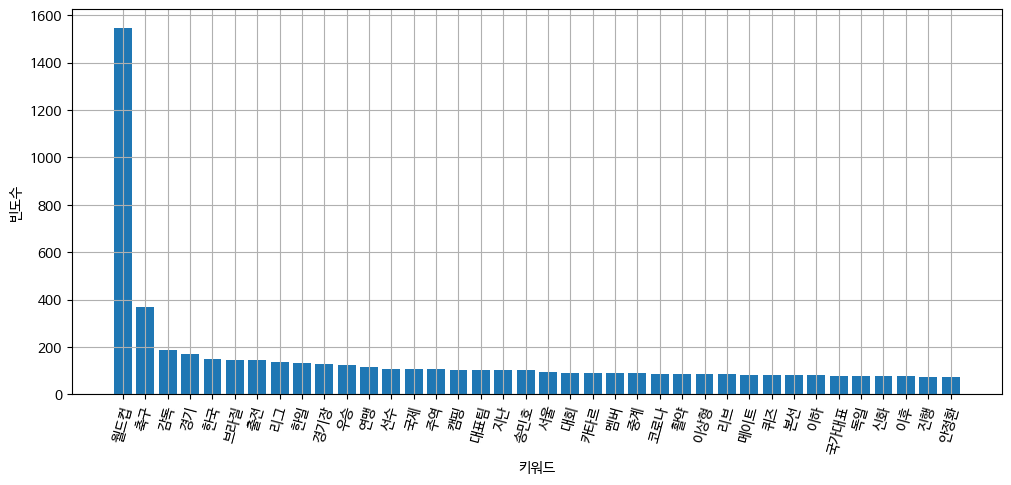

In [14]:
plt.figure(figsize = (12, 5))
plt.xlabel('키워드')
plt.ylabel('빈도수')
plt.grid(True)

sorted_Keys = sorted(word_count, key = word_count.get, reverse = True)
sorted_Values = sorted(word_count.values(), reverse = True)

plt.bar(range(len(word_count)), sorted_Values, align = 'center')
plt.xticks(range(len(word_count)), list(sorted_Keys), rotation = 75)

plt.show()

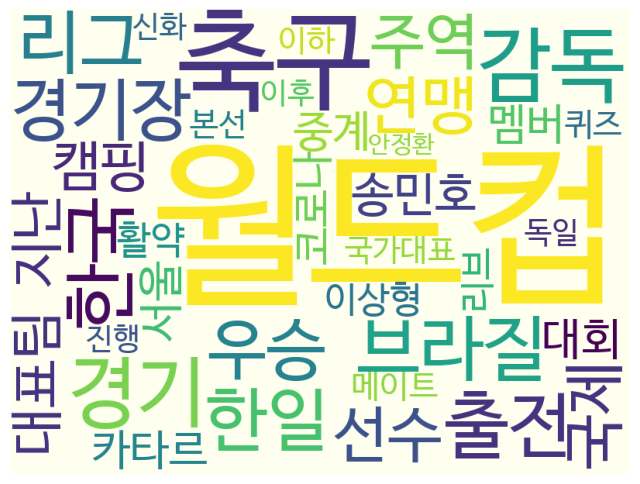

In [16]:
wc = WordCloud(font_path = 'NanumBarunGothic', background_color = 'ivory', width = 800, height = 600)
cloud = wc.generate_from_frequencies(word_count)
plt.figure(figsize = (8, 8))
plt.imshow(cloud)
plt.axis('off')
plt.show()